# Evaluation of a single DAG


## Setup

Let's assume we have a Directed Acyclic Graph (DAG), either produced by a causal discovery algorithm or hand-built. We want to characterise its structure both globally and at the Markov-blanket level.

In [1]:
"""Setup helpers for the bnm example notebooks.

These notebooks are intentionally self-contained: they use small local
utilities (random DAG generator, simple synthetic-data sampler, basic
PC-CPDAG construction) so a reader can run them with only ``bnm`` and
its optional ``[viz]`` extra installed. In production, prefer
``dagsampler`` for DAG construction and synthetic data and ``cbcd`` for
the PC algorithm and CPDAG output.
"""

import bnm
import numpy as np
import pandas as pd
import random
from collections import deque

# Configure plotly so figures render in any notebook viewer (JupyterLab,
# classic Notebook, nbviewer, GitHub's static renderer) instead of only
# emitting a vnd.plotly.v1+json mimetype.
import plotly.io as pio
pio.renderers.default = "notebook_connected+plotly_mimetype"


# ---- DAG / data generation (would normally come from dagsampler) ----

def random_dag(n_nodes=40, edge_prob=0.1, seed=None):
    """Return a bnm.GraphLike random DAG with X_1..X_n nodes."""
    rng = random.Random(seed)
    names = tuple(f"X_{i+1}" for i in range(n_nodes))
    topo = list(range(n_nodes))
    rng.shuffle(topo)
    endpoints = np.zeros((n_nodes, n_nodes), dtype=np.int8)
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            if rng.random() < edge_prob:
                src, dst = topo[i], topo[j]
                endpoints[src, dst] = bnm.EndpointMark.ARROW
                endpoints[dst, src] = bnm.EndpointMark.TAIL
    return bnm.to_graphlike(endpoints, var_names=names)


def generate_data(g, n_samples=1000, stdev=1.0, seed=None):
    """Linear-Gaussian SCM sampling. Returns a pandas DataFrame
    with columns matching g.var_names."""
    rng = np.random.default_rng(seed)
    n = g.n_vars
    names = list(g.var_names) if g.var_names else [str(i) for i in range(n)]
    arr = np.array(g.endpoints)
    children: list[list[int]] = [[] for _ in range(n)]
    in_deg = [0] * n
    for i in range(n):
        for j in range(n):
            if (
                arr[i, j] == bnm.EndpointMark.ARROW
                and arr[j, i] == bnm.EndpointMark.TAIL
            ):
                children[i].append(j)
                in_deg[j] += 1
    queue = deque(v for v in range(n) if in_deg[v] == 0)
    topo: list[int] = []
    while queue:
        v = queue.popleft()
        topo.append(v)
        for c in children[v]:
            in_deg[c] -= 1
            if in_deg[c] == 0:
                queue.append(c)
    data = pd.DataFrame(index=range(n_samples), columns=names, dtype=float)
    for v in topo:
        parents = [
            i for i in range(n)
            if arr[i, v] == bnm.EndpointMark.ARROW
            and arr[v, i] == bnm.EndpointMark.TAIL
        ]
        if not parents:
            data[names[v]] = rng.standard_normal(n_samples)
        else:
            weights = rng.uniform(0.5, 1.5, size=len(parents))
            x = rng.normal(0, stdev, size=n_samples)
            for p, w in zip(parents, weights):
                x = x + w * data[names[p]].values
            data[names[v]] = x
    return data


# ---- adjacency-matrix helpers ---------------------------------------

def from_01_adj(adj, var_names=None):
    """Convert a {0,1} adjacency matrix (1 = directed edge i→j) to a
    bnm.GraphLike. If both adj[i,j] == 1 and adj[j,i] == 1, the edge
    is treated as undirected (CPDAG-style)."""
    a = np.asarray(adj)
    n = a.shape[0]
    endpoints = np.zeros((n, n), dtype=np.int8)
    for i in range(n):
        for j in range(i + 1, n):
            ij, ji = int(a[i, j]), int(a[j, i])
            if ij == 1 and ji == 1:
                endpoints[i, j] = endpoints[j, i] = bnm.EndpointMark.TAIL
            elif ij == 1:
                endpoints[i, j] = bnm.EndpointMark.ARROW
                endpoints[j, i] = bnm.EndpointMark.TAIL
            elif ji == 1:
                endpoints[i, j] = bnm.EndpointMark.TAIL
                endpoints[j, i] = bnm.EndpointMark.ARROW
    names = tuple(var_names) if var_names is not None else None
    return bnm.to_graphlike(endpoints, var_names=names)


def dag_to_cpdag(g):
    """Convert a DAG to its CPDAG (without Meek-rule closure — same
    semantics as 0.1.x's `dag_to_cpdag`). For a Meek-closed CPDAG,
    use cbcd's `DAG.to_cpdag()` instead.
    """
    g = bnm.to_graphlike(g)
    n = g.n_vars
    arr = np.array(g.endpoints)
    in_collider = np.zeros((n, n), dtype=bool)
    for v in range(n):
        parents = [
            u for u in range(n)
            if arr[u, v] == bnm.EndpointMark.ARROW
            and arr[v, u] == bnm.EndpointMark.TAIL
        ]
        for ip in range(len(parents)):
            for jp in range(ip + 1, len(parents)):
                u, w = parents[ip], parents[jp]
                if (
                    arr[u, w] == bnm.EndpointMark.NO_EDGE
                    and arr[w, u] == bnm.EndpointMark.NO_EDGE
                ):
                    in_collider[u, v] = True
                    in_collider[w, v] = True
    cpdag = np.zeros((n, n), dtype=np.int8)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if (
                arr[i, j] == bnm.EndpointMark.ARROW
                and arr[j, i] == bnm.EndpointMark.TAIL
            ):
                if in_collider[i, j]:
                    cpdag[i, j] = bnm.EndpointMark.ARROW
                    cpdag[j, i] = bnm.EndpointMark.TAIL
                else:
                    cpdag[i, j] = bnm.EndpointMark.TAIL
                    cpdag[j, i] = bnm.EndpointMark.TAIL
    return bnm.to_graphlike(cpdag, var_names=g.var_names)


# ---- perturbation helper for "fake learned graph" demos ----------

def perturb(g, n_drops=0, n_adds=0, n_reverses=0, seed=None):
    """Return a perturbed copy of g: drop / add / reverse the requested
    number of directed edges. Used as a stand-in for a real causal-
    discovery output when we don't want to depend on a PC algorithm.

    For real workflows, swap this for `cbcd.pc(data, ...)` or any
    PC implementation whose output you can wrap in `from_01_adj()`.
    """
    g = bnm.to_graphlike(g)
    rng = random.Random(seed)
    arr = np.array(g.endpoints).copy()
    n = arr.shape[0]
    directed_edges = [
        (i, j) for i in range(n) for j in range(n)
        if arr[i, j] == bnm.EndpointMark.ARROW
        and arr[j, i] == bnm.EndpointMark.TAIL
    ]
    rng.shuffle(directed_edges)
    # Drops
    for k in range(min(n_drops, len(directed_edges))):
        i, j = directed_edges[k]
        arr[i, j] = arr[j, i] = bnm.EndpointMark.NO_EDGE
    remaining = directed_edges[n_drops:]
    # Reverses
    for k in range(min(n_reverses, len(remaining))):
        i, j = remaining[k]
        arr[i, j] = bnm.EndpointMark.TAIL
        arr[j, i] = bnm.EndpointMark.ARROW
    # Adds (only between currently-non-adjacent pairs to keep it a DAG-ish)
    non_edges = [
        (i, j) for i in range(n) for j in range(i + 1, n)
        if arr[i, j] == bnm.EndpointMark.NO_EDGE
    ]
    rng.shuffle(non_edges)
    for k in range(min(n_adds, len(non_edges))):
        i, j = non_edges[k]
        # Random direction
        if rng.random() < 0.5:
            arr[i, j] = bnm.EndpointMark.ARROW
            arr[j, i] = bnm.EndpointMark.TAIL
        else:
            arr[i, j] = bnm.EndpointMark.TAIL
            arr[j, i] = bnm.EndpointMark.ARROW
    return bnm.to_graphlike(arr, var_names=g.var_names)


# ---- viz helper: 0.1.x's compare_two_bn(option=2) ----------------

def mb_pair(g1, g2, var):
    """Return ``(g1.MB(var), g2 restricted to g1.MB(var) indices)``.
    Useful for side-by-side rendering of "true MB" vs "estimated MB
    over the same nodes." Replaces 0.1.x's ``compare_two_bn(option=2)``."""
    g1n, g2n = bnm.to_graphlike(g1), bnm.to_graphlike(g2)
    idx = bnm.markov_blanket_indices(g1n, var)
    sub_g1 = bnm.markov_blanket(g1n, var)
    arr2 = g2n.endpoints[np.ix_(idx, idx)]
    sub_names = (
        tuple(g2n.var_names[i] for i in idx) if g2n.var_names else None
    )
    sub_g2 = bnm.to_graphlike(arr2, var_names=sub_names)
    return sub_g1, sub_g2


print("bnm:", bnm.__version__)


bnm: 0.2.0.dev0


In [2]:
dag = random_dag(n_nodes=200, edge_prob=0.025, seed=55)
f'DAG with {dag.n_vars} variables, {bnm.count_edges(dag)} edges'

'DAG with 200 variables, 488 edges'

Three v0.2 features support systematic exploration of the DAG:

1. **`bnm.plot_graph(bnm.markov_blanket(g, var))`** — render the MB of any node.
2. **`bnm.compare(g, per_node=True)`** + `bnm.to_dataframe(...)` — per-MB descriptive table.
3. **`bnm.analyse_mb(g)`** — distribution of metrics across every MB.

## Feature 1 — plot Markov blankets of selected variables

Let's say we're interested in `X_32`. To inspect its causal neighbourhood, render its Markov blanket.

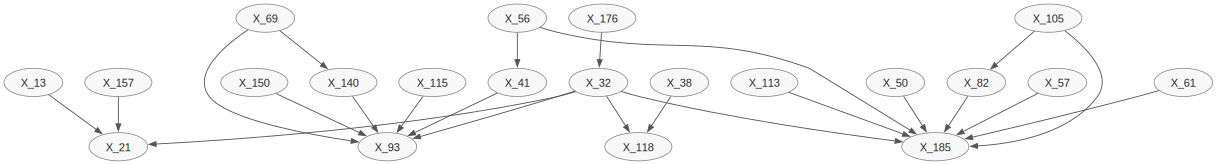

In [3]:
# Pick any node; we use X_32 (must exist for n_nodes=200).
target = 'X_32'
mb = bnm.markov_blanket(dag, target)
bnm.plot_graph(mb, title=f'Markov blanket of {target}', direction='auto')

Combining several MBs — e.g. inspect the path between two variables. We build a sub-graph over the union of their blankets and render it.

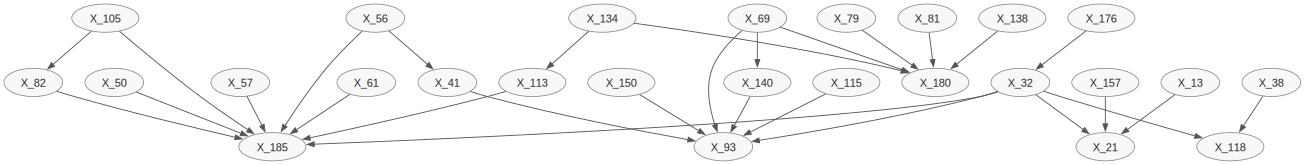

In [4]:
def union_mb(g, vars_):
    indices = sorted({i for v in vars_
                      for i in bnm.markov_blanket_indices(g, v)})
    arr = np.array(g.endpoints)[np.ix_(indices, indices)]
    names = tuple(g.var_names[i] for i in indices)
    return bnm.to_graphlike(arr, var_names=names)

bnm.plot_graph(
    union_mb(dag, ['X_32', 'X_180']),
    title='Markov blankets of X_32 and X_180',
    direction='auto',
)

## Feature 2 — comprehensive descriptive metrics

`bnm.compare(g, per_node=True)` computes every descriptive metric on the whole graph **and** on each variable's MB; `bnm.to_dataframe(c)` renders it as a wide table with one row per node plus an `'All'` row.

In [5]:
c = bnm.compare(dag, per_node=True)
df = bnm.to_dataframe(c)
df.head()

,node_name,n_edges,n_nodes,n_directed_arcs,n_undirected_arcs,n_bidirected_arcs,n_circle_edges,n_colliders,n_root_nodes,n_leaf_nodes,n_isolated_nodes,n_reversible_arcs
0,All,488.0,200.0,488.0,0.0,0.0,0.0,728.0,35.0,45.0,1.0,41.0
1,X_1,27.0,26.0,27.0,0.0,0.0,0.0,48.0,18.0,5.0,0.0,2.0
2,X_2,19.0,19.0,19.0,0.0,0.0,0.0,28.0,13.0,5.0,0.0,1.0
3,X_3,4.0,5.0,4.0,0.0,0.0,0.0,6.0,4.0,1.0,0.0,0.0
4,X_4,3.0,4.0,3.0,0.0,0.0,0.0,3.0,3.0,1.0,0.0,0.0


Find isolated nodes (nodes whose MB sub-graph has at least one isolated vertex):

In [6]:
isolated = df.query("node_name != 'All' and n_isolated_nodes > 0").node_name.tolist()
print(f'{len(isolated)} nodes whose MB contains an isolated vertex')
isolated[:10]

1 nodes whose MB contains an isolated vertex


['X_96']

Find the most complex Markov blanket (max edges):

most complex MB: X_181 (48.0 edges)


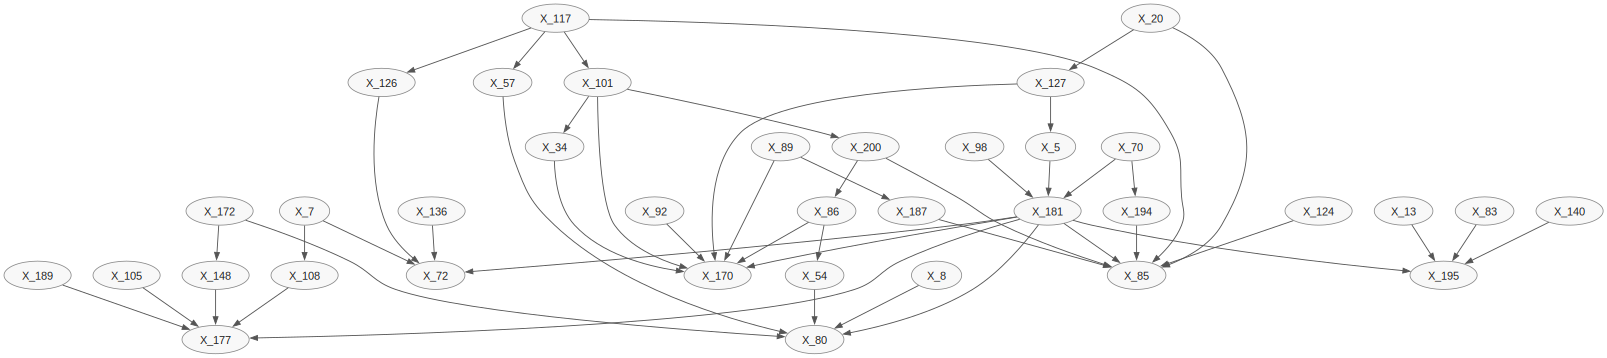

In [7]:
per_node = df[df.node_name != 'All']
max_edges = per_node['n_edges'].max()
complex_mb = per_node.loc[per_node['n_edges'] == max_edges, 'node_name'].iloc[0]
print(f'most complex MB: {complex_mb} ({max_edges} edges)')
bnm.plot_graph(
    bnm.markov_blanket(dag, complex_mb),
    title=f'MB of {complex_mb}',
    direction='auto',
)

## Feature 3 — analyse the MB space

`bnm.analyse_mb(g)` plots, for each descriptive metric, a value-count bar chart over the n MBs. Useful for characterising how heterogeneous the local structure is.

In [8]:
bnm.analyse_mb(dag)

## Conclusion

We explored a synthetic 1000-node DAG using three v0.2 features: per-node MB rendering (`plot_graph` + `markov_blanket`), the multi-metric per-node table (`compare` + `to_dataframe`), and the MB-space distribution (`analyse_mb`).

All viz functions accept a `save=` parameter that writes the figure to disk; the format is inferred from the file extension.

### Other Cases:
- [Compare Two DAGs](./compare_two_dags.ipynb)
- [Compare Algorithms](./compare_algorithms.ipynb)
- [SID](./sid.ipynb)